In [22]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [2]:
df = pd.read_csv('D:\\Voice Authetication ESPNET\\updated_speaker_info33_recognition_results66.csv')
df.head()

,Speaker,Audio_File,Recognized_Speaker,Distance,Result
0,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,Aamir_Khan,8.907205,0
1,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,10.693433,1
2,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,John_Abraham,9.181933,0
3,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,8.767502,1
4,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,11.917436,1


In [3]:
df['Recognized_Speaker'] = df['Recognized_Speaker'].str.rstrip('2')

In [4]:
df.head()

,Speaker,Audio_File,Recognized_Speaker,Distance,Result
0,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,Aamir_Khan,8.907205,0
1,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,10.693433,1
2,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,John_Abraham,9.181933,0
3,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,8.767502,1
4,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,11.917436,1


In [5]:
df['Result'] = (df['Speaker'] == df['Recognized_Speaker']).astype(int)

In [6]:
df.head()

,Speaker,Audio_File,Recognized_Speaker,Distance,Result
0,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,Aamir_Khan,8.907205,0
1,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,10.693433,1
2,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,John_Abraham,9.181933,0
3,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,8.767502,1
4,A.R.Rahman,D:\Voice Authetication ESPNET\datasetvox\vox1_...,A.R.Rahman,11.917436,1


In [7]:
# Print rows where the 'Result' is True (1)
correct_results = df[df['Result'] == 1]
print(correct_results['Speaker'])


1       A.R.Rahman
3       A.R.Rahman
4       A.R.Rahman
6       A.R.Rahman
7       A.R.Rahman
          ...     
959    Vidya_Balan
960    Vidya_Balan
971    Vidya_Balan
973    Vidya_Balan
977    Vidya_Balan
Name: Speaker, Length: 503, dtype: object


In [8]:
def normalize_name(name):
    return re.sub(r'[_\. ]', '', name.lower())  # Remove underscores, periods, and spaces, then lowercase



# Apply the normalization to both 'Speaker' and 'Recognized_Speaker' columns and compare
df['Result'] = df.apply(lambda row: 1 if normalize_name(row['Speaker']) == normalize_name(row['Recognized_Speaker']) else 0, axis=1)

In [9]:
# Print rows where the 'Result' is True (1)
correct_results = df[df['Result'] == 1]
print(correct_results['Speaker'])

1       A.R.Rahman
3       A.R.Rahman
4       A.R.Rahman
6       A.R.Rahman
7       A.R.Rahman
          ...     
959    Vidya_Balan
960    Vidya_Balan
971    Vidya_Balan
973    Vidya_Balan
977    Vidya_Balan
Name: Speaker, Length: 503, dtype: object


In [10]:
correct_results = df[df['Result'] == 1]
count_correct = correct_results.shape[0]  # Using shape
# or
count_correct = len(correct_results)  # Using len()

print(count_correct)


503


In [11]:
output_csv_path = 'D:\\Voice Authetication ESPNET\\updated_recognition_results33.csv'
df.to_csv(output_csv_path, index=False)

print(f"Recognition results saved to {output_csv_path}")


Recognition results saved to D:\Voice Authetication ESPNET\updated_recognition_results33.csv


In [12]:
total_samples = df.shape[0]
correct_samples = df[df['Result'] == 1].shape[0]
accuracy = correct_samples / total_samples

In [13]:

print(f"Total Samples: {total_samples}")
print(f"Correct Samples: {correct_samples}")
print(f"Accuracy: {accuracy:.2%}")




Total Samples: 990
Correct Samples: 503
Accuracy: 50.81%


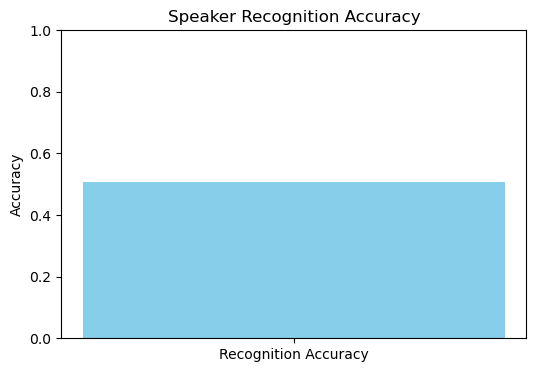

In [14]:
# Plotting Accuracy
plt.figure(figsize=(6, 4))
plt.bar(['Recognition Accuracy'], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Speaker Recognition Accuracy')
plt.show()

In [15]:
y_true = df['Speaker']
y_pred = df['Recognized_Speaker']
cm = confusion_matrix(y_true, y_pred)

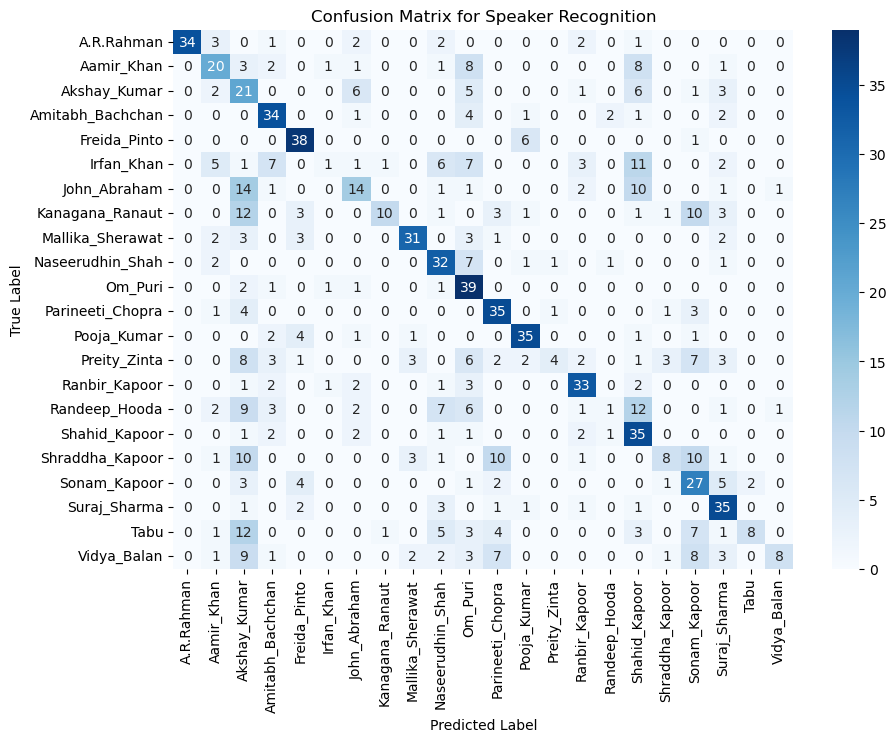

In [16]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df['Speaker'].unique(), yticklabels=df['Speaker'].unique())
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Speaker Recognition')
plt.show()

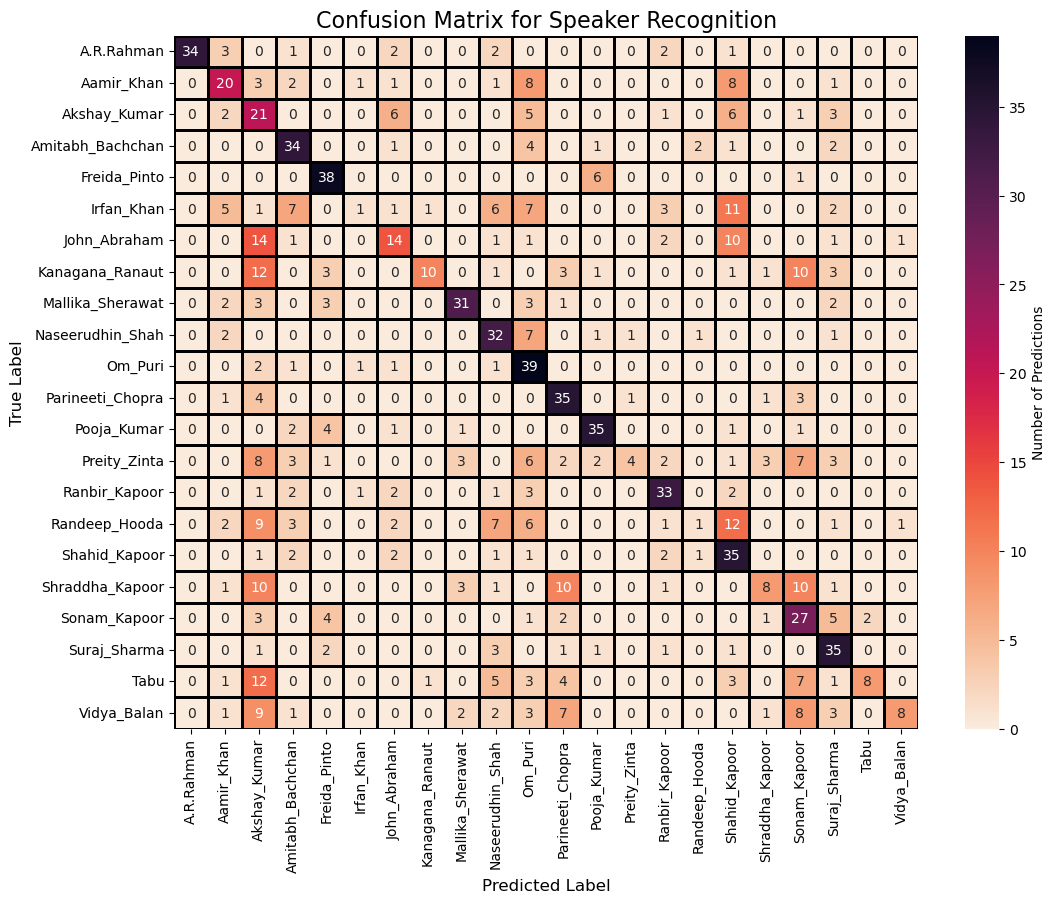

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure size
plt.figure(figsize=(12, 9))

# Plotting the heatmap with enhanced color palette, gridlines, and font sizes
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', linewidths=1, linecolor='black',
            xticklabels=df['Speaker'].unique(), yticklabels=df['Speaker'].unique(),
            cbar_kws={'label': 'Number of Predictions'})

# Setting axis labels and title with increased font sizes
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('Confusion Matrix for Speaker Recognition', fontsize=16)

# Rotating tick labels for better readability
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Display the plot
plt.show()



In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, F1-score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print additional metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Precision: 0.56
Recall: 0.51
F1 Score: 0.47


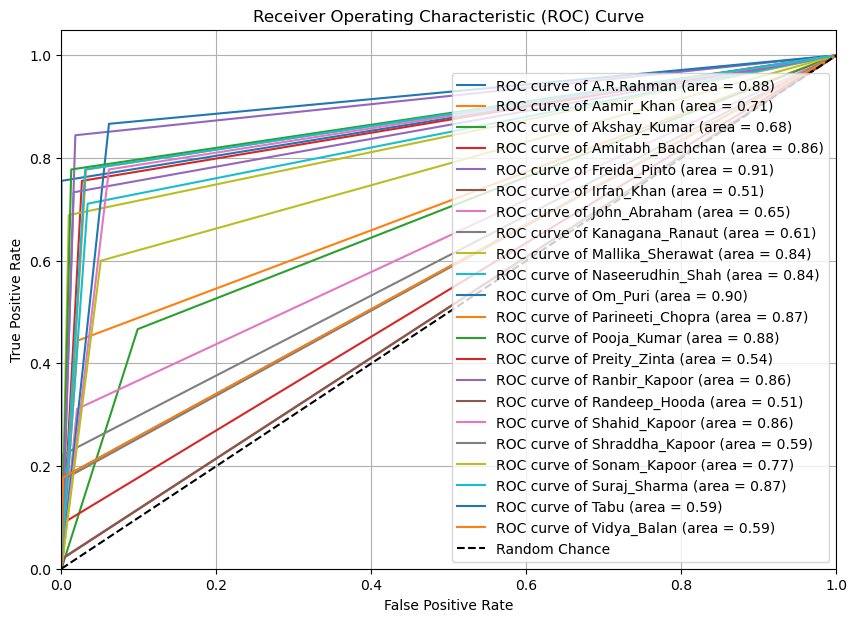

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assume you have a multi-class problem with unique speakers
unique_speakers = df['Speaker'].unique()
n_classes = len(unique_speakers)

# Binarize the output
y_true_binarized = label_binarize(y_true, classes=unique_speakers)
y_pred_binarized = label_binarize(y_pred, classes=unique_speakers)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of {unique_speakers[i]} (area = {roc_auc[i]:.2f})')

# Plot the diagonal line for a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [20]:
print("Hello")

Hello


In [24]:
## Calculate False Acceptance Rate (FAR) and False Rejection Rate (FRR)
false_acceptance = cm.sum(axis=0) - np.diag(cm)
false_rejection = cm.sum(axis=1) - np.diag(cm)
true_negatives = cm.sum() - (false_acceptance + false_rejection + np.diag(cm))

# FAR and FRR for each class
far = false_acceptance / (false_acceptance + true_negatives)
frr = false_rejection / (false_rejection + np.diag(cm))

# Print FAR and FRR for each class
for i, speaker in enumerate(unique_speakers):
    print(f"Speaker: {speaker}")
    print(f"False Acceptance Rate (FAR): {far[i]:.2%}")
    print(f"False Rejection Rate (FRR): {frr[i]:.2%}")

Speaker: A.R.Rahman
False Acceptance Rate (FAR): 0.00%
False Rejection Rate (FRR): 24.44%
Speaker: Aamir_Khan
False Acceptance Rate (FAR): 2.12%
False Rejection Rate (FRR): 55.56%
Speaker: Akshay_Kumar
False Acceptance Rate (FAR): 9.84%
False Rejection Rate (FRR): 53.33%
Speaker: Amitabh_Bachchan
False Acceptance Rate (FAR): 2.65%
False Rejection Rate (FRR): 24.44%
Speaker: Freida_Pinto
False Acceptance Rate (FAR): 1.80%
False Rejection Rate (FRR): 15.56%
Speaker: Irfan_Khan
False Acceptance Rate (FAR): 0.32%
False Rejection Rate (FRR): 97.78%
Speaker: John_Abraham
False Acceptance Rate (FAR): 2.01%
False Rejection Rate (FRR): 68.89%
Speaker: Kanagana_Ranaut
False Acceptance Rate (FAR): 0.21%
False Rejection Rate (FRR): 77.78%
Speaker: Mallika_Sherawat
False Acceptance Rate (FAR): 0.95%
False Rejection Rate (FRR): 31.11%
Speaker: Naseerudhin_Shah
False Acceptance Rate (FAR): 3.39%
False Rejection Rate (FRR): 28.89%
Speaker: Om_Puri
False Acceptance Rate (FAR): 6.14%
False Rejection Rat

In [25]:
# Calculate EER
eer = np.mean([far, frr], axis=0)
eer_index = np.nanargmin(np.abs(far - frr))
equal_error_rate = (far[eer_index] + frr[eer_index]) / 2

print(f"Equal Error Rate (EER): {equal_error_rate:.2%}")

Equal Error Rate (EER): 9.74%
